# Лабораторная работа № 5

# Многомерная регрессия

## Прогноз времени доставки еды

Датасет — `Food_Delivery_Times.csv`.

Набор данных предназначен для прогнозирования времени доставки еды с учетом различных факторов, таких как расстояние, погода, дорожная обстановка и время суток. Он представляет собой практическую и увлекательную задачу для специалистов по машинному обучению, особенно для тех, кто интересуется логистикой и исследованием операций.

Признаки:
- **Order_ID** — уникальный идентификатор для каждого заказа;
- **Distance_km** — расстояние доставки в километрах;
- **Weather** — погодные условия во время доставки, включая ясную, дождливую,
снежную, туманную и ветреную погоду;
- **Traffic_Level** —  классификация дорожных условий как низкие, средние или высокие;
- **Time_of_Day** —  время доставки, классифицированное как утро, день, вечер или
ночь;
- **Vehicle_Type** — тип транспортного средства, используемого для доставки,
включая велосипед, скутер и автомобиль;
- **Preparation_Time_min** —  время, необходимое для подготовки заказа в минутах;
- **Courier_Experience_yrs** — опыт работы курьера в годах;
- **Delivery_Time_min** — общее время доставки в минутах (целевая переменная).

# 0 шаг. Импортируем библиотеки и загружаем данные

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Food_Delivery_Times.csv')

# 1 шаг. Получим представление о наборе данных

In [2]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [3]:
print("Размер данных:", df.shape)

Размер данных: (1000, 9)


> По первым строкам видно, что датасет содержит сведения о заказах доставки еды: расстояние доставки, погодные условия, уровень трафика, время суток, тип транспорта, время подготовки заказа, опыт курьера и итоговое время доставки.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


> По результату `df.info()` видно, что в датасете есть числовые признаки типа `int64` и `float64`, а также категориальные признаки типа `object`. Также видно, что в некоторых столбцах присутствуют пропущенные значения, так как количество непустых значений меньше общего количества строк.

In [5]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


> Метод `describe()` показывает основные статистические характеристики числовых признаков. Целевая переменная `Delivery_Time_min` принимает значения от 8 до 153 минут. Среднее время доставки составляет примерно 56.73 минуты.

# 2 шаг. Произведем разведочный анализ данных

### Проанализируем целевую переменную

Для начала проанализируем распределение целевой переменной `Delivery_Time_min`, так как именно это значение будет прогнозировать модель линейной регрессии.

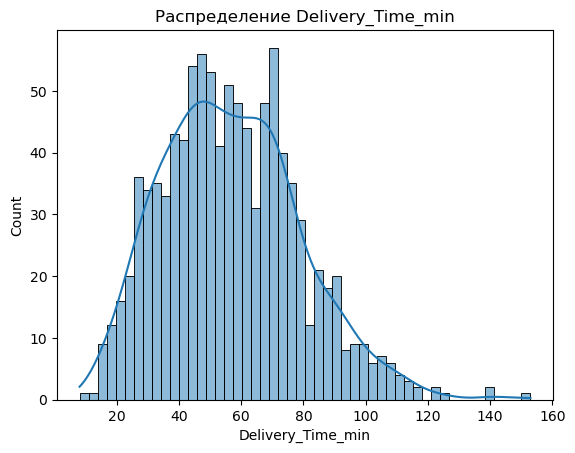

In [6]:
sns.histplot(df['Delivery_Time_min'], bins=50, kde=True, color='C0')
plt.title('Распределение Delivery_Time_min')
plt.show()

> По графику видно, что целевая переменная `Delivery_Time_min` имеет распределение, близкое к нормальному, но с небольшим смещением вправо. Большая часть заказов доставляется примерно за 30–80 минут. Очень большие значения времени доставки встречаются редко и могут быть связаны с большим расстоянием, плохими погодными условиями, высоким уровнем трафика или малым опытом курьера.

### Влияние расстояния доставки на время доставки

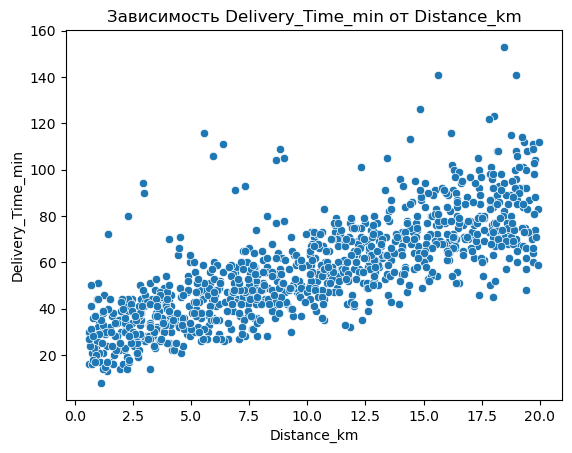

In [7]:
sns.scatterplot(x=df['Distance_km'], y=df['Delivery_Time_min'])
plt.title('Зависимость Delivery_Time_min от Distance_km')
plt.xlabel('Distance_km')
plt.ylabel('Delivery_Time_min')
plt.show()

> По графику видно, что при увеличении расстояния доставки общее время доставки обычно также увеличивается. Это логично, так как более длинный маршрут требует большего времени. Следовательно, признак `Distance_km` может быть важным для построения модели.

### Влияние времени подготовки заказа на время доставки

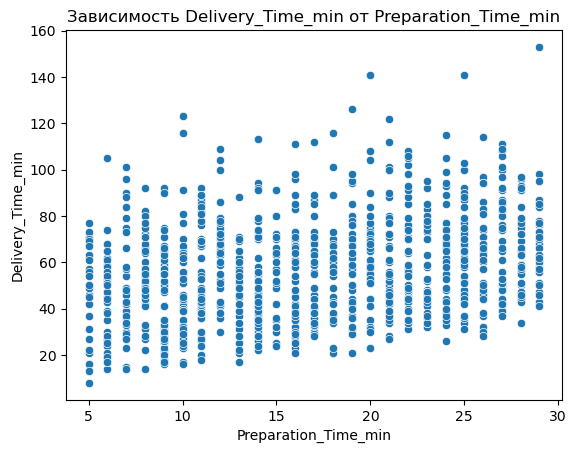

In [8]:
sns.scatterplot(x=df['Preparation_Time_min'], y=df['Delivery_Time_min'])
plt.title('Зависимость Delivery_Time_min от Preparation_Time_min')
plt.xlabel('Preparation_Time_min')
plt.ylabel('Delivery_Time_min')
plt.show()

> По графику видно, что время подготовки заказа связано с общим временем доставки. При увеличении `Preparation_Time_min` итоговое значение `Delivery_Time_min` также может увеличиваться. Поэтому данный признак имеет смысл использовать при обучении модели.

### Влияние уровня трафика на время доставки

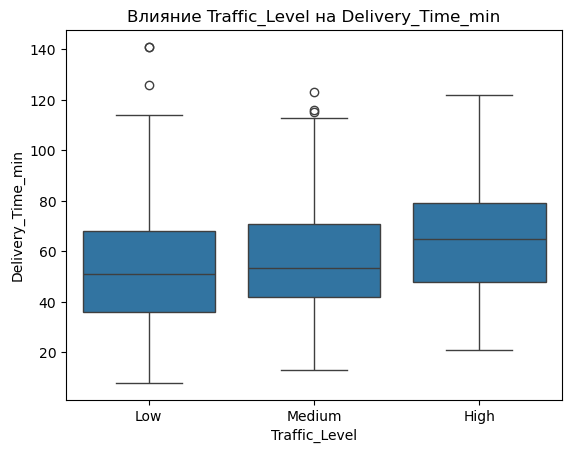

In [9]:
sns.boxplot(x='Traffic_Level', y='Delivery_Time_min', data=df)
plt.title('Влияние Traffic_Level на Delivery_Time_min')
plt.xlabel('Traffic_Level')
plt.ylabel('Delivery_Time_min')
plt.show()

> График показывает, что уровень дорожного трафика связан со временем доставки. При более высоком уровне трафика время доставки может увеличиваться, поэтому признак `Traffic_Level` может влиять на целевую переменную.

### Влияние погодных условий на время доставки

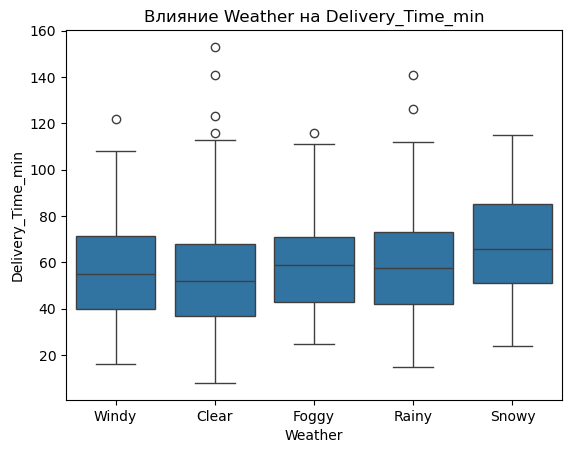

In [10]:
sns.boxplot(x='Weather', y='Delivery_Time_min', data=df)
plt.title('Влияние Weather на Delivery_Time_min')
plt.xlabel('Weather')
plt.ylabel('Delivery_Time_min')
plt.show()

> График показывает, что погодные условия могут влиять на время доставки. При неблагоприятной погоде время доставки может быть выше, поэтому признак `Weather` следует оставить для дальнейшего обучения модели.

### Корреляция числовых признаков

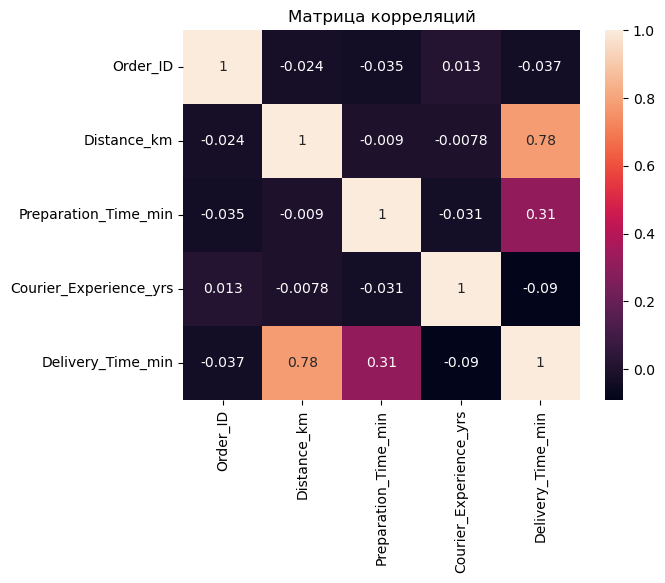

In [11]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Матрица корреляций')
plt.show()

> Матрица корреляций позволяет оценить связь числовых признаков с целевой переменной `Delivery_Time_min`. Признаки `Distance_km`, `Preparation_Time_min` и `Courier_Experience_yrs` могут использоваться для обучения модели. Признак `Order_ID` является идентификатором заказа и не несет содержательной информации для обучения модели.

# 3 шаг. Удалим несущественные признаки

In [12]:
df_copy = df.copy()
df_copy = df_copy.drop('Order_ID', axis=1)
df_copy.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68


> Признак `Order_ID` был удален, так как он является идентификатором заказа и не несет содержательной информации для обучения модели. Остальные признаки оставлены, так как они могут влиять на итоговое время доставки.

# 4 шаг. Проверяем наличие пропущенных значений

In [13]:
print(df_copy.isnull().sum())

Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64


> В датасете обнаружены пропущенные значения в нескольких столбцах. Перед обучением модели их необходимо обработать, так как модель линейной регрессии не работает с пропущенными значениями.

In [14]:
# заполним пропуски в категориальных признаках наиболее частым значением
df_copy['Weather'] = df_copy['Weather'].fillna(df_copy['Weather'].mode()[0])
df_copy['Traffic_Level'] = df_copy['Traffic_Level'].fillna(df_copy['Traffic_Level'].mode()[0])
df_copy['Time_of_Day'] = df_copy['Time_of_Day'].fillna(df_copy['Time_of_Day'].mode()[0])

# заполним пропуски в числовом признаке средним арифметическим через метод mean()
df_copy['Courier_Experience_yrs'] = df_copy['Courier_Experience_yrs'].fillna(df_copy['Courier_Experience_yrs'].mean())

In [15]:
# убедимся, что пропусков не осталось
print(df_copy.isnull().sum())

Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


> Пропущенные значения были обработаны: категориальные признаки заполнены наиболее частыми значениями, а числовой признак `Courier_Experience_yrs` заполнен средним арифметическим значением. После повторной проверки пропущенных значений не осталось.

# 5 шаг. Заменяем категориальные значения числовыми

In [16]:
print("Weather:", df_copy['Weather'].unique())
print("Traffic_Level:", df_copy['Traffic_Level'].unique())
print("Time_of_Day:", df_copy['Time_of_Day'].unique())
print("Vehicle_Type:", df_copy['Vehicle_Type'].unique())

Weather: ['Windy' 'Clear' 'Foggy' 'Rainy' 'Snowy']
Traffic_Level: ['Low' 'Medium' 'High']
Time_of_Day: ['Afternoon' 'Evening' 'Night' 'Morning']
Vehicle_Type: ['Scooter' 'Bike' 'Car']


In [17]:
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()

df_copy['Weather'] = labelencoder.fit_transform(df_copy['Weather'])
df_copy['Traffic_Level'] = labelencoder.fit_transform(df_copy['Traffic_Level'])
df_copy['Time_of_Day'] = labelencoder.fit_transform(df_copy['Time_of_Day'])
df_copy['Vehicle_Type'] = labelencoder.fit_transform(df_copy['Vehicle_Type'])

df_copy

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,4,1,0,2,12,1.0,43
1,16.42,0,2,1,0,20,2.0,84
2,9.52,1,1,3,2,28,1.0,59
3,7.44,2,2,0,2,5,1.0,37
4,19.03,0,1,2,0,16,5.0,68
...,...,...,...,...,...,...,...,...
995,8.50,0,0,1,1,13,3.0,54
996,16.28,2,1,2,2,8,9.0,71
997,15.62,3,0,1,2,26,2.0,81
998,14.17,0,1,0,0,8,0.0,55


> Категориальные признаки были преобразованы в числовые значения с помощью `LabelEncoder`. После кодирования все признаки представлены в числовом формате и могут использоваться для обучения модели линейной регрессии.

# 6 шаг. Разделяем данные на признаки и целевую переменную

In [18]:
y = df_copy['Delivery_Time_min']
X = df_copy.drop('Delivery_Time_min', axis=1)

# убедимся, что данные в нужном нам формате
type(X), type(y)

(pandas.core.frame.DataFrame, pandas.core.series.Series)

In [19]:
# посмотрим на признаки
X.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs
0,7.93,4,1,0,2,12,1.0
1,16.42,0,2,1,0,20,2.0
2,9.52,1,1,3,2,28,1.0
3,7.44,2,2,0,2,5,1.0
4,19.03,0,1,2,0,16,5.0


> Данные были разделены на матрицу признаков `X` и целевую переменную `y`. В качестве целевой переменной используется столбец `Delivery_Time_min`, остальные столбцы используются как признаки.

# 7 шаг. Разделяем данные на обучающую и тестовую выборку

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

75% данных используется для обучения модели и 25% — для тестирования. Разделение выполнено с помощью функции `train_test_split`.

# 8 шаг. Применяем операцию нормализации для численной устойчивости

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler

,copy,True
,with_mean,True
,with_std,True


In [22]:
X_train_scaled = scaler.fit_transform(X_train)  # обучаем и преобразуем тренировочные данные
X_test_scaled = scaler.transform(X_test)        # преобразуем тестовые данные теми же параметрами

> Масштабирование признаков выполнено с помощью `StandardScaler`. Для обучающей выборки используется `fit_transform`, а для тестовой — `transform`, чтобы параметры масштабирования определялись только по обучающим данным.

# 9 шаг. Обучаем модель линейной регрессии

In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(X_train_scaled, y_train)
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


> Модель линейной регрессии была обучена на масштабированных данных обучающей выборки.

# 10 шаг. Делаем прогноз на основе данных тестирования

In [24]:
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

# выведем первые пять значений с помощью диапазона индексов
y_pred_test[:5]

array([54.32427227, 30.28063323, 84.45639499, 36.95847762, 69.30697893])

> Модель построила прогнозы для обучающей и тестовой выборок. Для проверки были выведены первые пять предсказанных значений на тестовой выборке.

# 11 шаг. Оценка качества

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(y_true, y_pred, set_name=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"=== {set_name} ===")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R2 : {r2:.4f}")
    print()

evaluate_model(y_train, y_pred_train, "Train set")
evaluate_model(y_test, y_pred_test, "Test set")

=== Train set ===
MSE: 135.52
RMSE: 11.64
MAE: 7.62
R2 : 0.7134

=== Test set ===
MSE: 122.83
RMSE: 11.08
MAE: 7.35
R2 : 0.7673



> Для оценки качества модели были использованы метрики `MSE`, `RMSE`, `MAE` и `R2`. На обучающей выборке модель получила значение `R2 = 0.7134`, а на тестовой выборке `R2 = 0.7673`. Это означает, что модель объясняет примерно 76,73% изменчивости времени доставки на тестовых данных.

> Средняя абсолютная ошибка на тестовой выборке составила `MAE = 7.35` минуты, а корень из среднеквадратичной ошибки составил `RMSE = 11.08` минуты. Значения метрик на обучающей и тестовой выборках близки, поэтому можно сделать вывод, что модель не переобучилась и достаточно хорошо прогнозирует время доставки еды.

# 12 шаг. Итоговое уравнение

In [26]:
# Коэффициенты
print("Coefficients: ", model.coef_)

# Свободный член
print("Intercept: ", model.intercept_)

Coefficients:  [16.9463215   1.62679386 -1.42200354 -0.21457321 -0.04003275  6.77931449
 -1.70953983]
Intercept:  56.844


In [27]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,Distance_km,16.946322
1,Weather,1.626794
2,Traffic_Level,-1.422004
3,Time_of_Day,-0.214573
4,Vehicle_Type,-0.040033
5,Preparation_Time_min,6.779314
6,Courier_Experience_yrs,-1.709540


> Коэффициенты модели показывают влияние признаков на прогнозируемое время доставки. Так как признаки были масштабированы с помощью `StandardScaler`, коэффициенты можно сравнивать между собой по величине.

> Наибольшее положительное влияние на время доставки оказывает признак `Distance_km`: при увеличении расстояния доставки прогнозируемое время увеличивается. Также положительное влияние оказывает `Preparation_Time_min`, то есть при увеличении времени подготовки заказа итоговое время доставки также возрастает.

> Отрицательный коэффициент у признака `Courier_Experience_yrs` показывает, что при большем опыте курьера прогнозируемое время доставки уменьшается. Свободный член `Intercept` равен 56.844 и используется моделью как базовое значение в уравнении линейной регрессии.

# 13 шаг. Остатки регрессии

Построим график остатков регрессии. Остатки показывают разницу между фактическими и предсказанными значениями целевой переменной. Такой график позволяет проверить, есть ли у ошибок модели выраженный систематический паттерн.

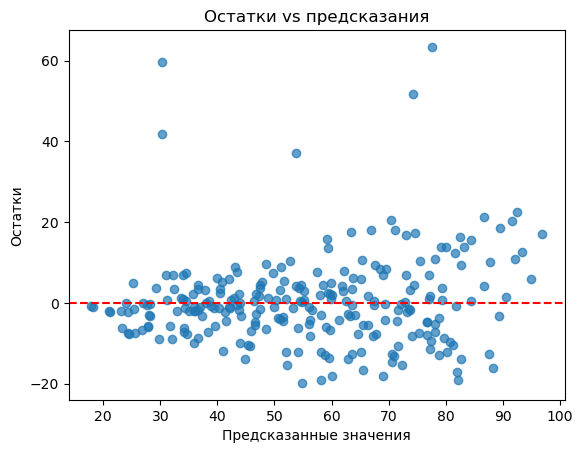

In [28]:
residuals = y_test - y_pred_test

plt.scatter(y_pred_test, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('Остатки vs предсказания')
plt.show()

> На графике остатки в основном расположены вокруг горизонтальной линии нуля. Это означает, что модель не имеет сильного систематического смещения в одну сторону. При этом заметны отдельные крупные ошибки, особенно для некоторых заказов со средним и высоким прогнозируемым временем доставки. В целом модель можно считать приемлемой, но она не идеально описывает все зависимости в данных.

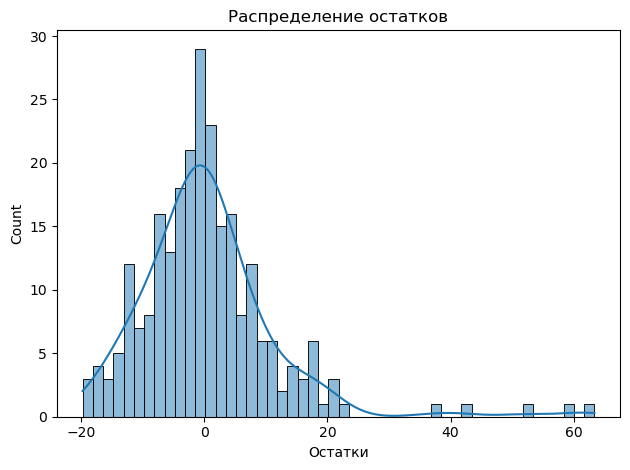

In [29]:
sns.histplot(residuals, bins=50, kde=True, color='C0')
plt.xlabel('Остатки')
plt.title('Распределение остатков')
plt.tight_layout()
plt.show()

> По графику видно, что основная часть остатков сосредоточена около нуля. Это означает, что для большинства объектов модель делает относительно небольшие ошибки. Распределение остатков имеет небольшой правый хвост: встречаются отдельные положительные остатки до 60 минут. Так как остаток считается как `y_test - y_pred_test`, положительные значения означают, что фактическое время доставки оказалось больше предсказанного. Следовательно, для некоторых заказов модель занижает прогноз времени доставки.

> В целом модель линейной регрессии показала приемлемое качество: значение `R2` на тестовой выборке равно `0.7673`, а средняя абсолютная ошибка составляет около `7.35` минуты. Модель можно использовать для приблизительного прогноза времени доставки еды, однако отдельные крупные ошибки показывают, что не все зависимости в данных описываются линейной моделью полностью.